# Ứng dụng GMM kết hợp HMM trong nhận diện hình vẽ tay

Notebook này trình bày cơ sở lý thuyết và cài đặt cho bài toán **nhận diện hình vẽ tay** dựa trên mô hình **GMM kết hợp HMM**, áp dụng cho bộ dữ liệu [Quick, Draw!](https://quickdraw.withgoogle.com/data) của Google.

---
# I) Cơ sở lý thuyết
---

## 1.1. Đặt vấn đề

Một hình vẽ tay (được vẽ bằng chuột/bút) không phải là một bức ảnh tĩnh, mà là **một chuỗi các điểm toạ độ theo thời gian** $O = (o_1, o_2, \dots, o_T)$, với $o_t = (x_t, y_t) \in \mathbb{R}^2$ là vị trí con trỏ tại thời điểm $t$. Đây chính xác là một **chuỗi thời gian nhiều chiều (multivariate time series)**.

Bài toán đặt ra: cho một chuỗi quan sát $O$, hãy xác định hình vẽ đó thuộc lớp nào trong tập các lớp đã biết (circle, square, triangle, zigzag, envelope, ...).

Hai mô hình được kết hợp để giải bài toán này:

- **GMM (Gaussian Mixture Model)**: mô hình hoá **phân phối của các điểm quan sát** (emission distribution) tại mỗi trạng thái ẩn.
- **HMM (Hidden Markov Model)**: mô hình hoá **sự phụ thuộc/chuyển tiếp theo thời gian** giữa các trạng thái ẩn (vd: trạng thái "đang vẽ cạnh trên" → "đang vẽ cạnh phải" của hình vuông).

Mỗi lớp hình vẽ sẽ có **1 mô hình HMM-GMM riêng**; khi cần phân loại, ta tính xác suất $P(O \mid \lambda_c)$ của chuỗi quan sát dưới từng mô hình lớp $\lambda_c$, và chọn lớp có xác suất cao nhất.

## 1.2. Gaussian Mixture Model (GMM)

GMM giả định dữ liệu được sinh ra từ tổ hợp tuyến tính của $K$ phân phối Gauss đa biến:

$$
p(x) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x \mid \mu_k, \Sigma_k)
$$

trong đó $\pi_k \geq 0$, $\sum_k \pi_k = 1$ là trọng số của thành phần $k$, và:

$$
\mathcal{N}(x \mid \mu_k, \Sigma_k) = \frac{1}{(2\pi)^{D/2} |\Sigma_k|^{1/2}} \exp\left(-\frac{1}{2}(x-\mu_k)^{T} \Sigma_k^{-1} (x-\mu_k)\right)
$$

với $D$ là số chiều của $x$ (ở đây $D=2$, ứng với $(x,y)$).

### Thuật toán EM (Expectation-Maximization)

Vì không biết trước điểm nào thuộc thành phần Gauss nào (biến ẩn $z_n$), ta dùng EM để ước lượng $\{\pi_k, \mu_k, \Sigma_k\}$ bằng cách lặp 2 bước:

**E-step** — tính trách nhiệm (responsibility) $\gamma(z_{nk})$: xác suất điểm $x_n$ thuộc thành phần $k$:

$$
\gamma(z_{nk}) = \frac{\pi_k \, \mathcal{N}(x_n \mid \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j \, \mathcal{N}(x_n \mid \mu_j, \Sigma_j)}
$$

**M-step** — cập nhật lại tham số dựa trên $\gamma(z_{nk})$ vừa tính:

$$
N_k = \sum_{n=1}^{N} \gamma(z_{nk})
\qquad
\mu_k = \frac{1}{N_k}\sum_{n=1}^{N} \gamma(z_{nk}) \, x_n
$$

$$
\Sigma_k = \frac{1}{N_k}\sum_{n=1}^{N} \gamma(z_{nk}) (x_n - \mu_k)(x_n - \mu_k)^{T}
\qquad
\pi_k = \frac{N_k}{N}
$$

Lặp lại E-step/M-step đến khi log-likelihood hội tụ:

$$
\ln p(X \mid \pi, \mu, \Sigma) = \sum_{n=1}^{N} \ln \left( \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x_n \mid \mu_k, \Sigma_k) \right)
$$

### Khởi tạo bằng K-means

EM rất nhạy với điểm khởi tạo (dễ hội tụ về cực trị địa phương xấu nếu khởi tạo ngẫu nhiên). Trong notebook này, tham số khởi tạo $(\pi^{(0)}, \mu^{(0)}, \Sigma^{(0)})$ được lấy từ kết quả phân cụm **K-means**: mean của mỗi cụm K-means làm $\mu_k^{(0)}$, tỉ lệ số điểm mỗi cụm làm $\pi_k^{(0)}$, và hiệp phương sai từng cụm làm $\Sigma_k^{(0)}$. Cách này giúp EM hội tụ nhanh hơn nhiều so với khởi tạo ngẫu nhiên.

## 1.3. Hidden Markov Model (HMM)

Một HMM được xác định bởi bộ tham số $\lambda = (A, B, \pi)$ với $N$ trạng thái ẩn được đánh số **từ 0 đến $N-1$**: $S = \{s_0, \dots, s_{N-1}\}$:

- **Ma trận chuyển trạng thái** $A = [a_{ij}]$, với $a_{ij} = P(q_{t+1}=s_j \mid q_t = s_i)$.
- **Phân phối phát xạ (emission)** $B = \{b_j(o_t)\}$, với $b_j(o_t) = P(o_t \mid q_t = s_j)$; trong bài toán này, $b_j$ là một GMM.
- **Phân phối trạng thái khởi tạo** $\pi = [\pi_i]$, với $\pi_i = P(q_1 = s_i)$.

### Thuật toán Forward

Để tính $P(O \mid \lambda)$ cho chuỗi quan sát $O=(o_1,\dots,o_T)$, dùng biến forward (Xác suất thu được chuỗi quan sát một phần o1 o2 ... ot ở trạng thái sj tại thời điểm t):

$$
\alpha_t(j) = P(o_1, \dots, o_t, q_t = s_j \mid \lambda), \qquad j=0,\dots,N-1
$$

Thuật toán Forward thực hiện 3 giai đoạn chính:  
**Giai đoạn khởi tạo** tại $t=1$:

$$
\alpha_1(j) = \pi_j b_j(o_1), \quad 1 \le j \le N
$$

Trong đó:  
$\pi_j = P(q_1 = s_j)$: Xác suất trạng thái ban đầu tại $t = 1$  
$b_j(o_1) = P(o_1 \mid q_1 = s_j)$: Xác suất phát xạ quan sát $o_1$ khi ở trạng thái $s_j$  
$N$: Tổng số trạng thái ẩn của mô hình  

**Giai đoạn quy nạp** với $t=1,\dots,T-1$:

$$
\alpha_{t+1}(j) = \left[\sum_{i=0}^{N-1}\alpha_t(i)a_{ij}\right]b_j(o_{t+1})
$$
Trong đó:  
$a_{ij} = P(q_{t+1} = s_j \mid q_t = s_i)$: Xác suất chuyển trạng thái từ $s_i$ sang $s_j$  
$b_j(o_{t+1})$: Xác suất phát xạ quan sát $o_{t+1}$ tại trạng thái $s_j$  
Tổng $\sum_{i=1}^N \alpha_t(i) a_{ij}$: Tổng xác suất đến được trạng thái $s_j$ tại thời điểm $t+1$ từ tất cả các trạng thái có thể có $s_i$ ở thời điểm $t$  

**Giai đoạn kết thúc**: Tổng xác suất của toàn bộ chuỗi quan sát $o$ cho bởi mô hình $\lambda$ là tổng của các biến $\alpha_T(j)$ ở bước thời điểm cuối cùng $T$

$$
P(O \mid \lambda) = \sum_{j=0}^{N-1}\alpha_T(j)
$$

### Cấu trúc forward-only (Bakis model) áp dụng cho bài toán này

Vì mỗi hình vẽ được biểu diễn theo một trình tự thời gian, ta dùng HMM **forward-only (Bakis model)**. Mô hình luôn bắt đầu ở trạng thái 0:

$$
\pi_0=1, \qquad \pi_j=0\quad (j>0)
$$

Với các trạng thái chưa phải trạng thái cuối, chuỗi chỉ có thể ở lại trạng thái hiện tại hoặc chuyển sang đúng trạng thái kế tiếp:

$$
a_{ij} = \begin{cases} p_{\text{self}} & j=i \\ 1-p_{\text{self}} & j=i+1 \\ 0 & \text{trường hợp khác} \end{cases}, \qquad i=0,\dots,N-2
$$

Ở trạng thái cuối, không còn trạng thái kế tiếp nên $a_{N-1,N-1}=1$. Khi tính forward, một trạng thái $j$ chỉ nhận đóng góp từ chính nó (self-loop) hoặc từ trạng thái liền trước $j-1$; đây là đúng với phần cài đặt log-domain bên dưới.

## 1.4. Kết hợp GMM-HMM

Với mỗi trạng thái ẩn $s_j$ của HMM, thay vì dùng 1 phân phối Gauss đơn, ta dùng 1 **GMM** làm phân phối phát xạ:

$$
b_j(o_t) = \sum_{k=1}^{K_j} \pi_{jk} \, \mathcal{N}(o_t \mid \mu_{jk}, \Sigma_{jk})
$$

Kiến trúc tổng thể: **GMM** đảm nhiệm việc mô tả "điểm quan sát tại 1 thời điểm/trạng thái trông như thế nào" (vd: cụm điểm nằm ở góc trên-trái của hình vuông), còn **HMM** đảm nhiệm việc mô tả "chuỗi các trạng thái đó nối tiếp nhau theo thời gian ra sao" (vd: từ góc trên-trái chuyển sang góc trên-phải). Đây chính là ý nghĩa của "mô hình hoá chuỗi thời gian nhiều chiều dựa trên GMM kết hợp với một mô hình chuỗi thời gian như HMM".

**Cách huấn luyện** trong notebook này: với mỗi lớp, chuẩn hoá từng mẫu vẽ rồi chia đều chuỗi điểm thành $N$ phần theo đúng thứ tự vẽ (mỗi phần ứng với 1 trạng thái), dồn các điểm cùng vị trí trạng thái của mọi mẫu trong lớp lại, rồi huấn luyện 1 GMM riêng cho trạng thái đó.

**Cách phân loại**: với 1 chuỗi quan sát mới, tính $P(O \mid \lambda_c)$ cho từng lớp $c$, chọn lớp có log-likelihood cao nhất:

$$
\hat{c} = \arg\max_{c} \; \log P(O \mid \lambda_c)
$$

---
# II) Cài đặt thuật toán và kết quả
---

## 2.1. Import thư viện và cấu hình

Toàn bộ GMM/EM/K-means được cài đặt thủ công bằng NumPy (không dùng `sklearn.mixture` hay `hmmlearn`). Chỉ dùng `scipy.special.logsumexp` để tính tổng log-xác suất ổn định số học (log-domain), và `matplotlib` để vẽ kết quả.

`CATEGORIES` là danh sách các lớp hình vẽ sẽ huấn luyện, đọc từ các file `.ndjson` (định dạng raw của QuickDraw) đặt trong thư mục `data/` cùng cấp với notebook.

In [ ]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

# 1. CẤU HÌNH
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(DATA_DIR, "training_output")
CATEGORIES = ["circle", "square", "triangle", "zigzag", "envelope"]
SAMPLES_PER_CLASS = 200      # số mẫu vẽ tối đa đọc từ mỗi file .ndjson
TEST_RATIO = 0.2             # tỉ lệ tách tập test
N_STATES = 4                 # số trạng thái ẩn, đánh số từ 0 đến N_STATES - 1
N_MIX = 2                    # số Gaussian component trong GMM của mỗi trạng thái
SELF_LOOP_PROB = 0.65        # xác suất ở lại ở các trạng thái chưa phải trạng thái cuối

EM_MAX_ITER = 100
EM_TOL = 1e-5
RANDOM_STATE = 42

MIN_POINTS_PER_SEQUENCE = N_STATES * 3   # bỏ mẫu vẽ quá ít điểm

MODEL_PATH = os.path.join(OUTPUT_DIR, "gmm_hmm_models.pkl")

## 2.2. Mật độ Gaussian đa biến 

Cài đặt công thức $\mathcal{N}(x \mid \mu, \Sigma)$ ở mục 1.2, tính theo **log-domain** rồi mới `exp()` ra để tránh tràn số (underflow) khi định thức $|\Sigma|$ rất nhỏ hoặc rất lớn. Nếu ma trận hiệp phương sai không xác định dương (do dữ liệu suy biến), cộng thêm 1 lượng nhỏ vào đường chéo để đảm bảo khả nghịch.

In [2]:
def gaussian_pdf(x, mean, cov):
    """Tính giá trị mật độ Gaussian đa biến cho một hoặc nhiều điểm."""
    x = np.asarray(x, dtype=float)
    mean = np.asarray(mean, dtype=float)
    cov = np.asarray(cov, dtype=float)

    original_shape = x.shape
    if x.ndim == 1:
        x = x.reshape(1, -1)

    diff = x - mean
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        cov = cov + 1e-6 * np.eye(cov.shape[0])
        sign, logdet = np.linalg.slogdet(cov)

    inv_cov = np.linalg.inv(cov)
    quad = np.einsum('ij,jk,ik->i', diff, inv_cov, diff)
    d = mean.shape[0]
    log_pdf = -0.5 * (d * np.log(2 * np.pi) + logdet + quad)
    vals = np.exp(log_pdf)
    return float(vals[0]) if original_shape == (d,) else vals

## 2.3. E-step

Cài đặt công thức $\gamma(z_{nk})$ ở mục 1.2: tính xác suất hậu nghiệm mỗi điểm thuộc về từng thành phần Gauss, dùng `logsumexp` để chuẩn hoá theo hàng một cách ổn định số học (tránh chia cho số quá nhỏ).

In [3]:
def e_step(X, pi, means, covs):
    """E-step: tính responsibility R[n, k] = p(z_n=k | x_n, theta)."""
    N, D = X.shape
    K = len(pi)
    log_prob = np.empty((N, K))
    for k in range(K):
        pdf = gaussian_pdf(X, means[k], covs[k])
        pdf = np.clip(pdf, 1e-300, None)
        log_prob[:, k] = np.log(np.clip(pi[k], 1e-300, None)) + np.log(pdf)
    log_total = logsumexp(log_prob, axis=1, keepdims=True)
    R = np.exp(log_prob - log_total)
    return R

## 2.4. M-step 

Cài đặt công thức cập nhật $N_k, \mu_k, \Sigma_k, \pi_k$ ở mục 1.2 từ ma trận trách nhiệm `R` vừa tính ở E-step. Nếu 1 thành phần "chết" (không có điểm nào thuộc về nó, $N_k \approx 0$), fallback về mean/cov của toàn bộ dữ liệu để tránh chia cho 0.

In [4]:
def m_step(X, R):
    """M-step: cập nhật pi, means, covs từ R[n, k]."""
    N, D = X.shape
    K = R.shape[1]
    Nk = R.sum(axis=0)

    pi = Nk / N
    means = np.empty((K, D))
    covs = np.empty((K, D, D))
    for k in range(K):
        if Nk[k] < 1e-12:
            means[k] = X.mean(axis=0)
            covs[k] = np.cov(X.T) + 1e-6 * np.eye(D)
            continue
        means[k] = (R[:, k][:, None] * X).sum(axis=0) / Nk[k]
        diff = X - means[k]
        cov = (R[:, k][:, None, None] * diff[:, :, None] * diff[:, None, :]).sum(axis=0) / Nk[k]
        cov = 0.5 * (cov + cov.T)
        cov += 1e-6 * np.eye(D)
        covs[k] = cov

    return pi, means, covs

## 2.5. Log-likelihood tổng thể

Tính $\ln p(X \mid \pi, \mu, \Sigma)$ theo công thức ở mục 1.2 — giá trị này được theo dõi qua từng vòng lặp EM để kiểm tra sự hội tụ (dùng cho `ll_history` ở phần vẽ kết quả).

In [5]:
def log_likelihood(X, pi, means, covs):
    """Tính log-likelihood của toàn bộ dữ liệu."""
    total = np.zeros(X.shape[0])
    for k in range(len(pi)):
        total += pi[k] * gaussian_pdf(X, means[k], covs[k])
    total = np.clip(total, 1e-300, None)
    return np.sum(np.log(total))

## 2.6. K-means thủ công
Cài đặt K-means kinh điển (gán nhãn theo khoảng cách Euclid gần nhất → cập nhật lại centroid) để dùng làm bước khởi tạo cho EM (mục 1.2). Dừng sớm nếu nhãn không đổi giữa 2 vòng lặp liên tiếp.

In [6]:
def kmeans(X, K, max_iter=100, random_state=0):
    """K-means cài đặt thủ công """
    rng = np.random.default_rng(random_state)
    centers = X[rng.choice(X.shape[0], size=K, replace=False)].copy()
    labels = np.zeros(X.shape[0], dtype=int)
    for _ in range(max_iter):
        distances = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        new_labels = distances.argmin(axis=1)
        if np.all(new_labels == labels):
            break
        labels = new_labels
        new_centers = np.empty_like(centers)
        for k in range(K):
            if np.any(labels == k):
                new_centers[k] = X[labels == k].mean(axis=0)
            else:
                new_centers[k] = centers[k]
        centers = new_centers

    return labels, centers

## 2.7. Khởi tạo GMM từ K-means 

Dùng kết quả phân cụm K-means ở trên để khởi tạo $(\pi^{(0)}, \mu^{(0)}, \Sigma^{(0)})$ cho GMM, như đã giải thích ở mục 1.2 — giúp EM hội tụ nhanh hơn nhiều so với khởi tạo ngẫu nhiên.

In [7]:
def initialize_gmm_from_kmeans(X, K, random_state=0):
    """Khởi tạo tham số GMM (pi, means, covs) bằng kết quả phân cụm K-means."""
    labels_init, centers_init = kmeans(X, K=K, random_state=random_state)
    N, D = X.shape

    pi0 = np.array([np.mean(labels_init == k) for k in range(K)])
    means0 = centers_init.copy()

    covs0 = np.zeros((K, D, D))
    for k in range(K):
        pts = X[labels_init == k]
        if len(pts) > 1:
            covs0[k] = np.cov(pts.T) + 1e-6 * np.eye(D)
        else:
            covs0[k] = np.cov(X.T) + 1e-6 * np.eye(D)

    return pi0, means0, covs0

## 2.8. Vòng lặp EM đầy đủ 

Ghép E-step + M-step thành 1 vòng lặp hoàn chỉnh, dừng khi log-likelihood hội tụ (thay đổi giữa 2 vòng liên tiếp nhỏ hơn `EM_TOL`) hoặc đạt `EM_MAX_ITER`. Trả về cả `ll_history` để vẽ đường cong hội tụ ở phần sau.

In [8]:
def gmm_em_from_init(X, pi0, means0, covs0, max_iter=EM_MAX_ITER, tol=EM_TOL):
    """Chạy thuật toán EM cho GMM, xuất phát từ tham số khởi tạo bằng K-means."""
    pi, means, covs = pi0.copy(), means0.copy(), covs0.copy()
    ll_history = []
    prev_ll = -np.inf

    for it in range(1, max_iter + 1):
        R = e_step(X, pi, means, covs)
        pi, means, covs = m_step(X, R)
        ll = log_likelihood(X, pi, means, covs)
        ll_history.append(ll)
        if abs(ll - prev_ll) < tol:
            break
        prev_ll = ll

    return pi, means, covs, R, ll_history

## 2.9. Đọc dữ liệu QuickDraw 

Đọc file `.ndjson` (định dạng raw, có toạ độ gốc) của 1 category, chỉ giữ lại các bản vẽ có `recognized: true` (được game AI xác nhận vẽ đúng), gộp toạ độ tất cả các nét (stroke) thành 1 chuỗi điểm `(T, 2)` theo đúng thứ tự vẽ. Bỏ qua các mẫu quá ít điểm (`MIN_POINTS_PER_SEQUENCE`).

In [9]:
def load_category_sequences(category, data_dir, limit):
    """Đọc file .ndjson raw của 1 category, trả về list các chuỗi điểm (T,2)."""
    filename = category.replace(" ", "_") + ".ndjson"
    path = os.path.join(data_dir, filename)
    sequences = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if len(sequences) >= limit:
                break
            obj = json.loads(line)
            if not obj.get("recognized", True):
                continue  # bỏ các bản vẽ bị người chơi vẽ sai/không rõ
            points = []
            for stroke in obj["drawing"]:
                xs, ys = stroke[0], stroke[1]
                points.extend(zip(xs, ys))

            if len(points) < MIN_POINTS_PER_SEQUENCE:
                continue
            sequences.append(np.array(points, dtype=float))
    return sequences

## 2.10. Chuẩn hoá và chia trạng thái 

- `normalize_sequence`: trừ mean, chia std cho từng mẫu vẽ — giúp model bất biến với vị trí và tỉ lệ vẽ khác nhau giữa các lần vẽ.
- `segment_sequence`: chia đều chuỗi điểm đã chuẩn hoá thành `n_states` phần liên tiếp theo đúng thứ tự vẽ — đây là cách khởi tạo gán nhãn trạng thái cho mô hình forward-only đã nêu ở mục 1.3/1.4 (vd: hình vuông chia thành 4 phần ứng với 4 cạnh).

In [10]:
def normalize_sequence(points):
    """Chuẩn hoá 1 chuỗi điểm: trừ mean, chia std."""
    mean = points.mean(axis=0)
    std = points.std(axis=0)
    std = np.where(std < 1e-6, 1e-6, std)
    return (points - mean) / std
def segment_sequence(points, n_states):
    """Chia chuỗi điểm (đã chuẩn hoá) thành n_states phần liên tiếp theo đúng
    thứ tự vẽ - đây chính là cách khởi tạo trạng thái mà bài báo đề xuất cho
    forward-only HMM (vd: circle chia thành 4 phần = 4 quadrant)."""
    T = len(points)
    boundaries = np.linspace(0, T, n_states + 1).astype(int)
    segments = []
    for i in range(n_states):
        seg = points[boundaries[i]:boundaries[i + 1]]
        if len(seg) == 0:
            idx = min(boundaries[i], T - 1)
            seg = points[idx:idx + 1]
        segments.append(seg)
    return segments

## 2.11. Tách tập train/test 

Xáo trộn ngẫu nhiên (có `random_state` cố định để tái lập kết quả) rồi tách theo tỉ lệ `TEST_RATIO`.

In [11]:
def train_test_split(sequences, test_ratio, random_state):
    rng = np.random.default_rng(random_state)
    idx = rng.permutation(len(sequences))
    n_test = max(1, int(len(sequences) * test_ratio))
    test_idx, train_idx = idx[:n_test], idx[n_test:]
    return [sequences[i] for i in train_idx], [sequences[i] for i in test_idx]

## 2.12. Emission log-probability của một trạng thái

Tính $\log b_j(o_t)$ theo công thức GMM emission ở mục 1.4 cho một điểm quan sát $o_t$ tại trạng thái $s_j$. Trong code, `gmm_state_log_prob` tính $\log\left(\sum_k \pi_{jk}\mathcal{N}(o_t\mid\mu_{jk},\Sigma_{jk})\right)$ trực tiếp từ các tham số GMM của trạng thái đó.

In [12]:
def gmm_state_log_prob(x, gmm):
    """log p(x | trạng thái) với emission là GMM nhiều component."""
    total = 0.0
    for k in range(len(gmm["pi"])):
        total += gmm["pi"][k] * gaussian_pdf(x, gmm["means"][k], gmm["covs"][k])
    total = max(total, 1e-300)
    return np.log(total)

## 2.13. Thuật toán Forward (log-domain) 

Cài đặt chính xác công thức forward ở mục 1.3, với cấu trúc forward-only: tại mỗi bước thời gian, $\alpha_t(j)$ chỉ có thể nhận đóng góp từ $\alpha_{t-1}(j)$ (ở lại) hoặc $\alpha_{t-1}(j-1)$ (từ trạng thái liền trước) — dùng `logsumexp` để cộng 2 xác suất này trong log-domain một cách ổn định số học.

In [13]:
def forward_log_likelihood(points, model):
    """Tính log P(O|lambda) bằng thuật toán forward ở log-domain.


    - Trạng thái khởi đầu: luôn bắt đầu ở trạng thái 0.
    - Với trạng thái đích j, chỉ nhận đóng góp từ j (ở lại) hoặc j - 1
      (chuyển tiếp từ trạng thái liền trước).
    - Trạng thái cuối có self-loop xác suất 1 vì không còn trạng thái kế tiếp.
    """
    n_states = model["n_states"]
    log_next = np.log(model["next_prob"])
    gmms = model["gmms"]
    log_alpha = np.full(n_states, -np.inf)
    log_alpha[0] = gmm_state_log_prob(points[0], gmms[0])  # pi_0 = 1
    for t in range(1, len(points)):
        new_log_alpha = np.full(n_states, -np.inf)
        for j in range(n_states):
            stay_prob = 1.0 if j == n_states - 1 else model["self_prob"]
            log_stay = np.log(stay_prob)
            terms = []
            if log_alpha[j] > -np.inf:
                terms.append(log_alpha[j] + log_stay)
            if j > 0 and log_alpha[j - 1] > -np.inf:
                terms.append(log_alpha[j - 1] + log_next)
            if terms:
                b_j = gmm_state_log_prob(points[t], gmms[j])
                new_log_alpha[j] = logsumexp(terms) + b_j
        log_alpha = new_log_alpha
        if np.all(np.isneginf(log_alpha)):
            break
    return logsumexp(log_alpha)

## 2.14. Huấn luyện 1 mô hình HMM-GMM cho 1 lớp 

Ghép toàn bộ các bước ở mục 1.4 lại: với mỗi mẫu vẽ trong tập train của 1 lớp, chuẩn hoá rồi chia thành `n_states` phần; dồn các điểm cùng vị trí trạng thái của mọi mẫu lại; huấn luyện 1 GMM riêng (K-means init + EM, mục 2.6-2.8) cho từng trạng thái.

In [ ]:
def train_class_model(category, train_sequences, n_states, n_mix,
                       self_prob, random_state):
    """Huấn luyện 1 HMM-GMM forward-only cho 1 lớp cử chỉ.

    Bước khởi tạo: chuẩn hoá từng mẫu vẽ, chia đều thành n_states
    phần theo thứ tự vẽ, dồn toàn bộ điểm cùng vị trí trạng thái của mọi mẫu
    trong lớp lại -> huấn luyện 1 GMM (kmeans-init + EM) riêng cho trạng thái đó.
    """
    state_points = [[] for _ in range(n_states)]
    for seq in train_sequences:
        norm = normalize_sequence(seq)
        segments = segment_sequence(norm, n_states)
        for s, seg in enumerate(segments):
            state_points[s].extend(seg.tolist())
    gmms, ll_histories = [], []
    for s in range(n_states):
        X_s = np.array(state_points[s])
        if len(X_s) < 2:
            X_s = np.vstack([X_s, X_s + 1e-3]) if len(X_s) == 1 else \
                  np.random.default_rng(random_state).normal(size=(4, 2))
        k = max(1, min(n_mix, len(X_s) // 3))
        pi0, means0, covs0 = initialize_gmm_from_kmeans(X_s, K=k, random_state=random_state)
        pi_f, means_f, covs_f, _, ll_hist = gmm_em_from_init(X_s, pi0, means0, covs0)

        gmms.append({"pi": pi_f, "means": means_f, "covs": covs_f})
        ll_histories.append(ll_hist)
    return {
        "category": category,
        "n_states": n_states,
        "self_prob": self_prob,
        "next_prob": 1.0 - self_prob,
        "gmms": gmms,
        "ll_histories": ll_histories,
        "state_points": state_points,
    }

def predict(points, models):
    """Phân loại 1 chuỗi điểm: chọn model có log-likelihood cao nhất."""
    norm = normalize_sequence(points)
    scores = {cat: forward_log_likelihood(norm, m) for cat, m in models.items()}
    best_cat = max(scores, key=scores.get)
    return best_cat, scores

## 2.15. Xuất và nạp model 

Sau khi train xong, lưu toàn bộ tham số cần cho việc suy luận ra file `.pkl`, để dùng lại cho việc nhận diện sau này mà không cần train lại từ đầu.

In [15]:
def save_models(models, path):
    """Lưu toàn bộ model (1 HMM-GMM / lớp) ra file .pkl để dùng lại cho việc
    inference sau này (vd nạp vào app "Draw something!") mà không cần train lại.

    Chỉ lưu phần tham số cần cho việc suy luận (n_states, self_prob, next_prob,
    gmms) - bỏ "state_points" và "ll_histories" (chỉ dùng để vẽ plot, không cần
    cho lúc predict) để file gọn hơn.
    """
    export = {}
    for cat, model in models.items():
        export[cat] = {
            "category": model["category"],
            "n_states": model["n_states"],
            "self_prob": model["self_prob"],
            "next_prob": model["next_prob"],
            "gmms": model["gmms"],
        }

    with open(path, "wb") as f:
        pickle.dump({"categories": list(models.keys()), "models": export}, f)

    size_kb = os.path.getsize(path) / 1024
    print(f"[LƯU MODEL] {path} ({size_kb:.1f} KB)")
def load_models(path):
    """Nạp lại model đã lưu bằng save_models(). Trả về dict {category: model}
    dùng trực tiếp được với hàm predict()."""
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data["models"]

## 2.16. Các hàm vẽ kết quả


In [16]:
def plot_em_convergence(models, output_dir):
    """Vẽ đường cong hội tụ log-likelihood của EM cho từng trạng thái, mỗi lớp
    1 subplot - minh hoạ hiệu quả của việc khởi tạo bằng K-means."""
    n_cat = len(models)
    fig, axes = plt.subplots(1, n_cat, figsize=(4.2 * n_cat, 4), squeeze=False)
    axes = axes[0]

    for ax, (cat, model) in zip(axes, models.items()):
        for s, ll_hist in enumerate(model["ll_histories"]):
            ax.plot(range(1, len(ll_hist) + 1), ll_hist, marker='o',
                    markersize=3, linewidth=1.5, label=f"state {s}")
        ax.set_title(f"'{cat}' - EM convergence")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Log-likelihood")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    path = os.path.join(output_dir, "01_em_convergence.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"[LƯU] {path}")


def plot_state_gaussians(model, output_dir):
    """Vẽ các điểm đã gán theo trạng thái + contour Gaussian đã học được,
    cho 1 lớp cử chỉ minh hoạ (giống style contour trong notebook gốc)."""
    n_states = model["n_states"]
    colors = plt.cm.tab10(np.linspace(0, 1, n_states))

    all_points = np.vstack(model["state_points"])
    min_x, max_x = all_points[:, 0].min() - 1, all_points[:, 0].max() + 1
    min_y, max_y = all_points[:, 1].min() - 1, all_points[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(min_x, max_x, 120), np.linspace(min_y, max_y, 120))
    grid = np.column_stack([xx.ravel(), yy.ravel()])

    fig, ax = plt.subplots(figsize=(7, 6))
    for s in range(n_states):
        pts = np.array(model["state_points"][s])
        ax.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.4, color=colors[s],
                   label=f"state {s}")
        gmm = model["gmms"][s]
        for k in range(len(gmm["pi"])):
            Z = gaussian_pdf(grid, gmm["means"][k], gmm["covs"][k]).reshape(xx.shape)
            ax.contour(xx, yy, Z, levels=5, colors=[colors[s]], alpha=0.8)

    ax.set_title(f"GMM đã học theo từng trạng thái - lớp '{model['category']}'")
    ax.set_xlabel("x (đã chuẩn hoá)")
    ax.set_ylabel("y (đã chuẩn hoá)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    path = os.path.join(output_dir, f"02_state_gaussians_{model['category']}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"[LƯU] {path}")


def plot_confusion_matrix(y_true, y_pred, categories, output_dir):
    n = len(categories)
    idx = {c: i for i, c in enumerate(categories)}
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[idx[t], idx[p]] += 1

    fig, ax = plt.subplots(figsize=(1.4 * n + 2, 1.4 * n + 2))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(n)); ax.set_xticklabels(categories, rotation=45, ha="right")
    ax.set_yticks(range(n)); ax.set_yticklabels(categories)
    ax.set_xlabel("Dự đoán"); ax.set_ylabel("Thực tế")
    ax.set_title("Confusion matrix - tập test")

    for i in range(n):
        for j in range(n):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    path = os.path.join(output_dir, "03_confusion_matrix.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"[LƯU] {path}")
    return cm


def plot_accuracy_bar(y_true, y_pred, categories, output_dir):
    accs = []
    for cat in categories:
        idxs = [i for i, t in enumerate(y_true) if t == cat]
        correct = sum(1 for i in idxs if y_pred[i] == cat)
        accs.append(correct / len(idxs) if idxs else 0.0)

    overall = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)

    fig, ax = plt.subplots(figsize=(1.4 * len(categories) + 2, 4.5))
    bars = ax.bar(categories, accs, color="tab:blue", alpha=0.8)
    ax.axhline(overall, color="red", linestyle="--", label=f"Trung bình = {overall:.2%}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy theo từng lớp trên tập test")
    ax.legend()
    for b, a in zip(bars, accs):
        ax.text(b.get_x() + b.get_width() / 2, a + 0.02, f"{a:.0%}", ha="center")

    plt.tight_layout()
    path = os.path.join(output_dir, "04_accuracy_per_class.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"[LƯU] {path}")
    return overall

## 2.17. Đọc dữ liệu

Đọc dữ liệu cho từng category trong `CATEGORIES`, tách train/test theo `TEST_RATIO`.

In [17]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_data, test_data = {}, {}
for cat in CATEGORIES:
    seqs = load_category_sequences(cat, DATA_DIR, SAMPLES_PER_CLASS)
    train_seqs, test_seqs = train_test_split(seqs, TEST_RATIO, RANDOM_STATE)
    train_data[cat], test_data[cat] = train_seqs, test_seqs
    print(f"  {cat:12s}: {len(train_seqs)} mẫu train, {len(test_seqs)} mẫu test")

  circle      : 160 mẫu train, 40 mẫu test
  square      : 160 mẫu train, 40 mẫu test
  triangle    : 160 mẫu train, 40 mẫu test
  zigzag      : 160 mẫu train, 40 mẫu test
  envelope    : 160 mẫu train, 40 mẫu test


**Nhận xét:** số mẫu train/test hiển thị ở trên phản ánh số bản vẽ hợp lệ (`recognized: true` và đủ số điểm tối thiểu) đọc được từ mỗi file `.ndjson`, giới hạn bởi `SAMPLES_PER_CLASS`. Nếu 1 lớp có số mẫu ít hơn hẳn các lớp còn lại, đó có thể là dấu hiệu file `.ndjson` của lớp đó thiếu, hoặc ngưỡng `MIN_POINTS_PER_SEQUENCE` đang lọc bỏ quá nhiều mẫu vẽ ngắn của lớp đó — cần kiểm tra lại nếu accuracy của lớp này thấp bất thường ở bước đánh giá phía dưới.

## 2.18. Huấn luyện HMM-GMM cho từng lớp

In [18]:
models = {}
for cat in CATEGORIES:
    print(f"Đang huấn luyện '{cat}' ...")
    model = train_class_model(cat, train_data[cat], N_STATES, N_MIX,
                               SELF_LOOP_PROB, RANDOM_STATE)
    models[cat] = model
    total_iters = sum(len(h) for h in model["ll_histories"])
    print(f"  -> Tổng số vòng lặp EM qua {N_STATES} trạng thái: {total_iters}")

save_models(models, MODEL_PATH)

Đang huấn luyện 'circle' ...
  -> Tổng số vòng lặp EM qua 4 trạng thái: 348
Đang huấn luyện 'square' ...
  -> Tổng số vòng lặp EM qua 4 trạng thái: 272
Đang huấn luyện 'triangle' ...
  -> Tổng số vòng lặp EM qua 4 trạng thái: 180
Đang huấn luyện 'zigzag' ...
  -> Tổng số vòng lặp EM qua 4 trạng thái: 324
Đang huấn luyện 'envelope' ...
  -> Tổng số vòng lặp EM qua 4 trạng thái: 320
[LƯU MODEL] e:\Project\GMMxHMMquickdraw\data\training_output\gmm_hmm_models.pkl (4.7 KB)


**Nhận xét:** tổng số vòng lặp EM in ra cho biết tốc độ hội tụ của từng lớp — nhờ khởi tạo bằng K-means (mục 2.7), EM thường hội tụ khá nhanh (thường dưới vài chục vòng lặp mỗi trạng thái) thay vì phải chạy hết `EM_MAX_ITER=100`. Model sau khi train được lưu ra `gmm_hmm_models.pkl` để dùng lại cho việc suy luận về sau mà không cần train lại.

## 2.19.Đánh giá trên tập test

In [19]:
y_true, y_pred = [], []
for cat in CATEGORIES:
    for seq in test_data[cat]:
        pred_cat, _ = predict(seq, models)
        y_true.append(cat)
        y_pred.append(pred_cat)

overall_acc = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)
print(f"Accuracy tổng thể trên tập test: {overall_acc:.2%}")

Accuracy tổng thể trên tập test: 75.50%


**Nhận xét:** accuracy tổng thể là chỉ số tóm tắt nhanh, nhưng không cho biết lớp nào đang bị nhầm với lớp nào — cần xem tiếp `confusion matrix` ở mục 2.22 để phân tích chi tiết hơn.

## 2.20. Plot 1 — Đường cong hội tụ EM 

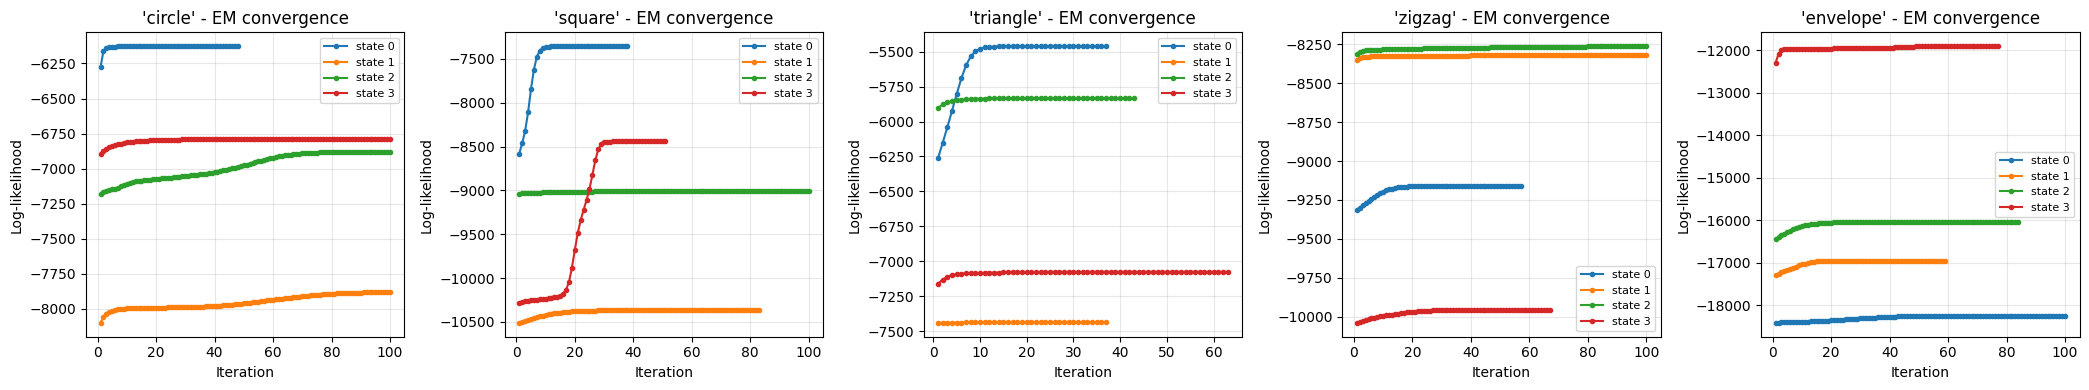

[LƯU] e:\Project\GMMxHMMquickdraw\data\training_output\01_em_convergence.png


In [20]:
plot_em_convergence(models, OUTPUT_DIR)

**Nhận xét:** đường cong cho biết log-likelihood của từng GMM theo số vòng lặp EM. Nếu đường cong còn tăng khi chạm `EM_MAX_ITER`, trạng thái tương ứng chưa hội tụ hoàn toàn; nếu gần như phẳng từ sớm, khởi tạo K-means đã ở gần nghiệm ổn định. Kết luận cụ thể cần dựa trên output được tạo từ lần chạy hiện tại.

## 2.21. Plot 2 — Gaussian đã học theo từng trạng thái 

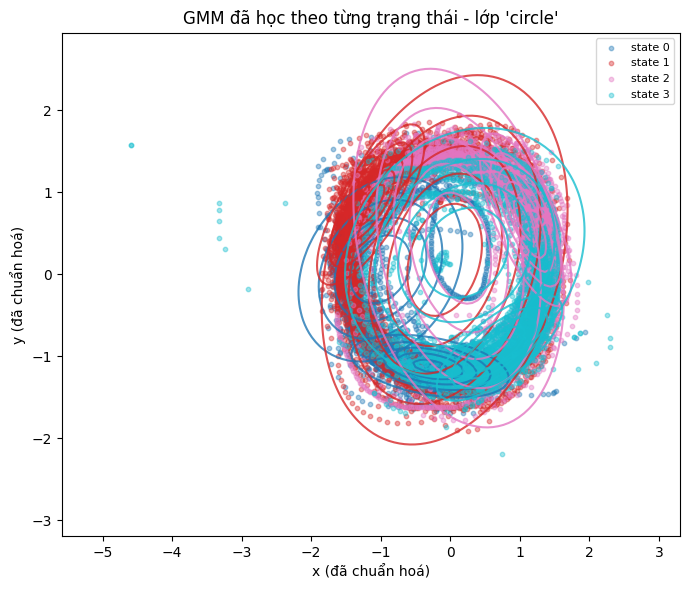

[LƯU] e:\Project\GMMxHMMquickdraw\data\training_output\02_state_gaussians_circle.png


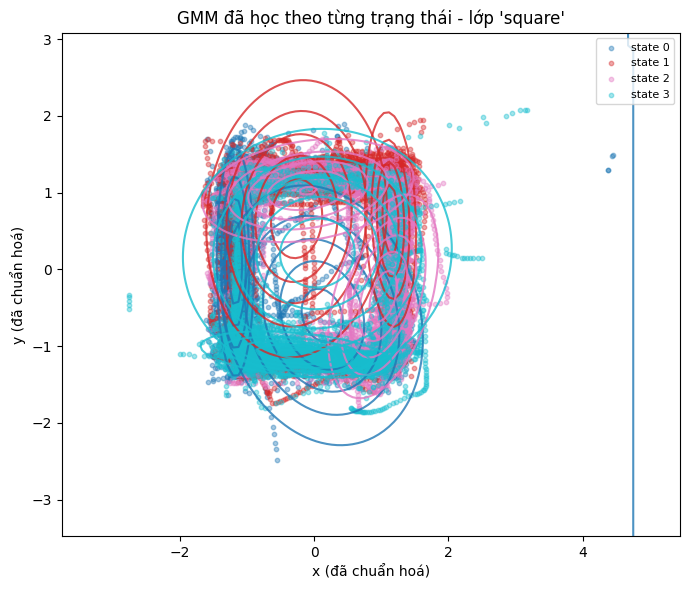

[LƯU] e:\Project\GMMxHMMquickdraw\data\training_output\02_state_gaussians_square.png


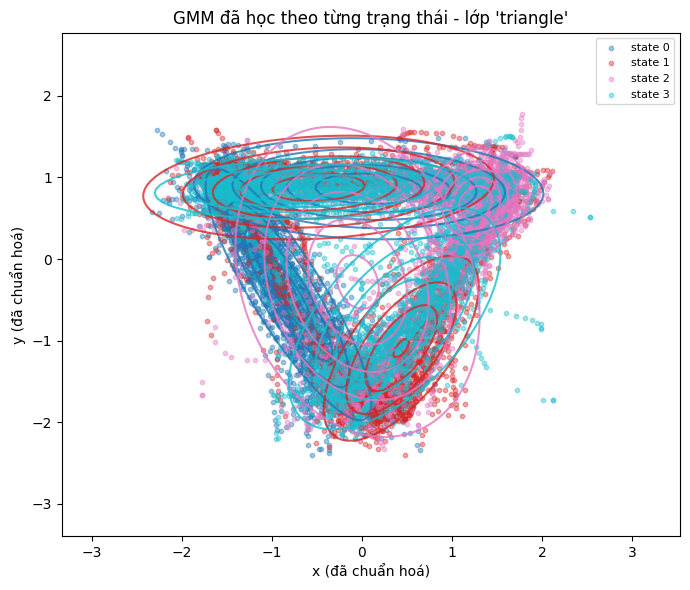

[LƯU] e:\Project\GMMxHMMquickdraw\data\training_output\02_state_gaussians_triangle.png


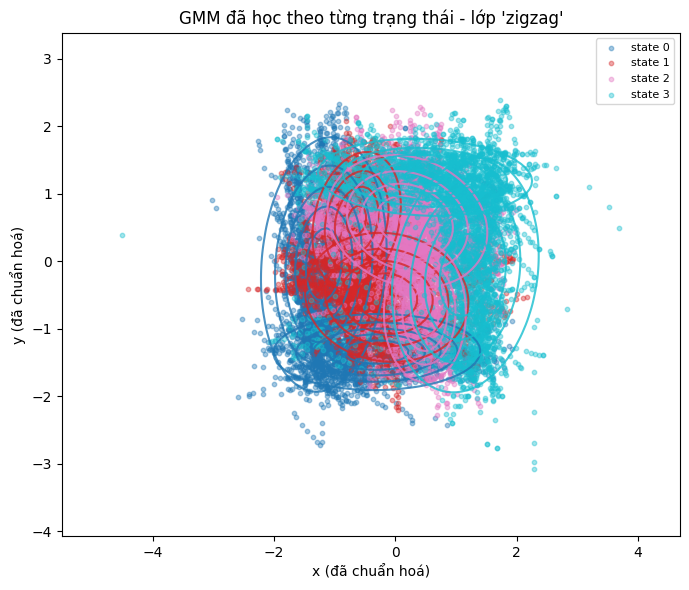

[LƯU] e:\Project\GMMxHMMquickdraw\data\training_output\02_state_gaussians_zigzag.png


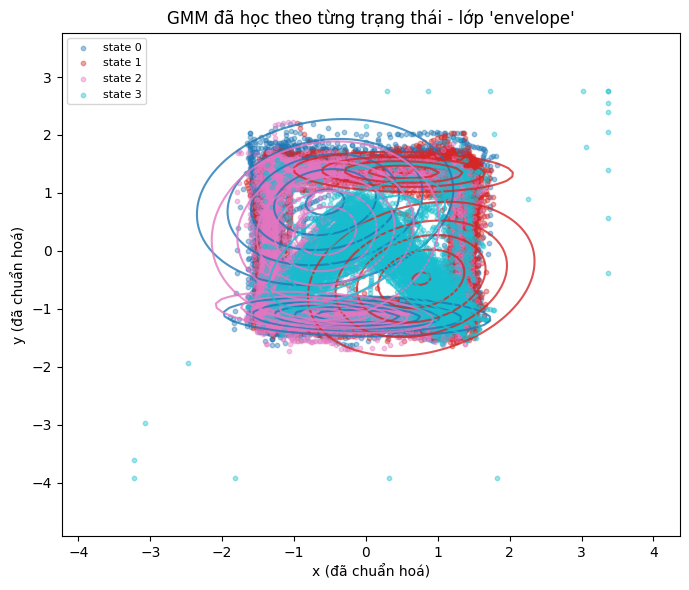

[LƯU] e:\Project\GMMxHMMquickdraw\data\training_output\02_state_gaussians_envelope.png


In [25]:
plot_state_gaussians(models[CATEGORIES[0]], OUTPUT_DIR)  # minh hoạ lớp đầu tiên
plot_state_gaussians(models[CATEGORIES[1]], OUTPUT_DIR)  # minh hoạ lớp đầu tiên
plot_state_gaussians(models[CATEGORIES[2]], OUTPUT_DIR)  # minh hoạ lớp đầu tiên
plot_state_gaussians(models[CATEGORIES[3]], OUTPUT_DIR)  # minh hoạ lớp đầu tiên
plot_state_gaussians(models[CATEGORIES[4]], OUTPUT_DIR)  # minh hoạ lớp đầu tiên

**Nhận xét:** đây là điểm đáng chú ý nhất trong notebook — 4 cụm điểm theo màu (ứng với 4 trạng thái) của lớp `circle` **chồng lấn gần như hoàn toàn** lên nhau trên cùng 1 vùng không gian, thay vì tách thành 4 góc phần tư riêng biệt như kỳ vọng ở mục 1.4. Nguyên nhân: `segment_sequence` chia trạng thái theo **chỉ số điểm** (index), ngầm giả định mọi mẫu vẽ hình tròn đều bắt đầu từ cùng 1 vị trí và cùng chiều vẽ — nhưng thực tế người chơi QuickDraw có thể bắt đầu vẽ từ bất kỳ điểm nào trên vòng tròn, theo chiều kim đồng hồ hoặc ngược lại. Vì vậy "trạng thái 0" của mẫu này có thể ứng với góc trên-trái, nhưng ở mẫu khác lại ứng với góc dưới-phải — khiến GMM của từng trạng thái phải học một hỗn hợp dữ liệu đến từ nhiều vị trí hình học khác nhau. Đây chính là nguyên nhân cốt lõi khiến `circle` có accuracy thấp nhất trong 5 lớp (65%, xem mục 2.23).

## 2.22. Plot 3 — Confusion matrix 

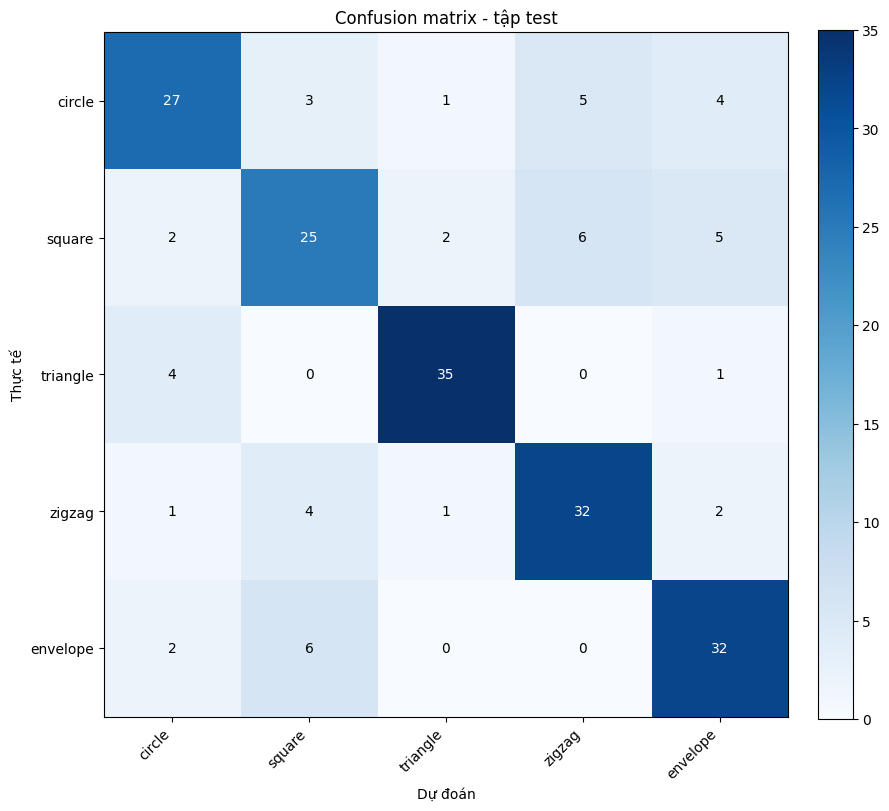

[LƯU] e:\Project\GMMxHMMquickdraw\data\training_output\03_confusion_matrix.png


In [22]:
cm = plot_confusion_matrix(y_true, y_pred, CATEGORIES, OUTPUT_DIR)

**Nhận xét:** mỗi hàng của confusion matrix là lớp thực tế, mỗi cột là lớp dự đoán. Các phần tử trên đường chéo là số mẫu được nhận diện đúng; phần tử ngoài đường chéo cho biết các cặp lớp đang bị nhầm lẫn. Vì mô hình dùng log-likelihood forward của từng HMM-GMM, cần đọc ma trận cùng với cách chia trạng thái và chất lượng GMM của từng lớp.

## 2.23. Plot 4 — Accuracy theo từng lớp 

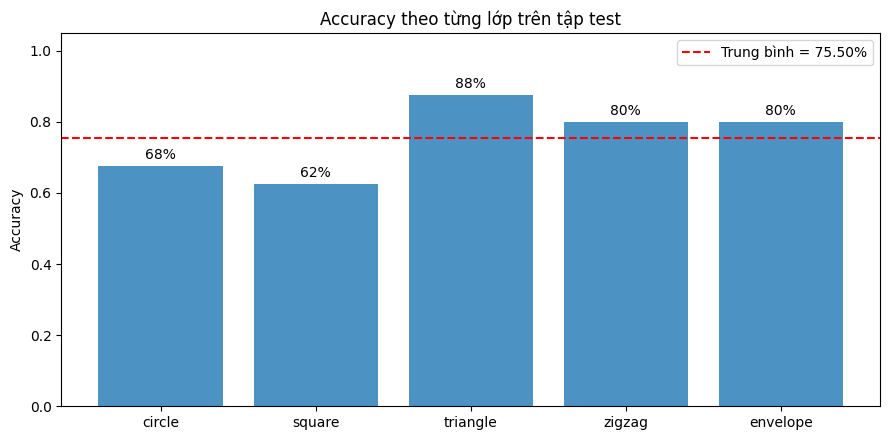

[LƯU] e:\Project\GMMxHMMquickdraw\data\training_output\04_accuracy_per_class.png


In [23]:
overall = plot_accuracy_bar(y_true, y_pred, CATEGORIES, OUTPUT_DIR)

**Nhận xét:** biểu đồ hiển thị accuracy của từng lớp và đường ngang là accuracy tổng thể trên tập test. Các lớp có accuracy thấp cần được phân tích cùng confusion matrix và cách chia chuỗi thành trạng thái; không nên suy ra nguyên nhân chỉ từ một con số tổng thể.